# Logistic Regression in R

## Overview

Logistic regression models the probability of a binary outcome (0/1, yes/no, present/absent) as a function of one or more predictors. Rather than predicting the outcome directly, it models the **log-odds** (logit) of the outcome, which is then transformed to a probability via the logistic function.

| Model | Use Case |
|---|---|
| Binary logistic regression | Two-category outcome (the most common case) |
| Logistic regression with interactions | Effect of one predictor on odds depends on another |
| Logistic regression with offset | Accounting for unequal exposure or sampling effort |

> **Key output: odds ratios (OR)**  
> OR > 1: predictor increases the odds of the outcome  
> OR < 1: predictor decreases the odds of the outcome  
> OR = 1: no association

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | What environmental variables predict species presence vs. absence? Does sediment treatment predict bivalve survival (survived/died)? Do habitat characteristics predict nest success? |
| **Healthcare** | What patient characteristics predict disease diagnosis (yes/no)? What factors predict 30-day hospital readmission? |
| **Finance** | What features predict loan default (default/no default)? What transaction characteristics predict fraud? |
| **Insurance** | What policyholder characteristics predict whether a claim is filed? What factors predict claim approval vs. denial? |

---

## Assumptions Checklist

- [ ] **Binary outcome:** Response variable has exactly two categories (coded 0/1)
- [ ] **Independence:** Observations are independent — no repeated measures or clustering
- [ ] **Linearity of log-odds:** Each continuous predictor has a linear relationship with the log-odds of the outcome (check with Box-Tidwell test or smoothed residual plots)
- [ ] **No perfect separation:** No predictor (or combination) perfectly predicts the outcome — causes complete separation and unstable estimates
- [ ] **No severe multicollinearity:** Check with VIF as in linear regression
- [ ] **Adequate sample size:** At least 10-20 events (occurrences of the less frequent outcome) per predictor — the 'events per variable' (EPV) rule

> **Logistic regression does NOT assume:**  
> - Normally distributed residuals  
> - Homoscedasticity  
> - Linear relationship between predictors and the raw outcome

---

## Setup

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
library(tidyverse)    # data manipulation and visualization
library(ggplot2)      # visualization
library(car)          # VIF, Box-Tidwell test
library(pROC)         # ROC curves and AUC
library(performance)  # model diagnostics
library(effectsize)   # odds ratios with CIs
library(broom)        # tidy model output
library(ResourceSelection) # Hosmer-Lemeshow goodness-of-fit

# ── Reproducibility ──────────────────────────────────────────────────────────
set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'car' was built under R version 4.4.3"
Loading required package: carData

Warning message:
"package 'carDat

## Data

We use the built-in `mtcars` dataset, recoding transmission type (`am`: 0 = automatic, 1 = manual) as the binary outcome, predicted by vehicle weight and horsepower. This is a clean, zero-dependency example — the same structure applies directly to species presence/absence, disease diagnosis, or loan default.


automatic    manual 
       19        13 


automatic    manual 
  0.59375   0.40625 

`geom_smooth()` using formula = 'y ~ x'


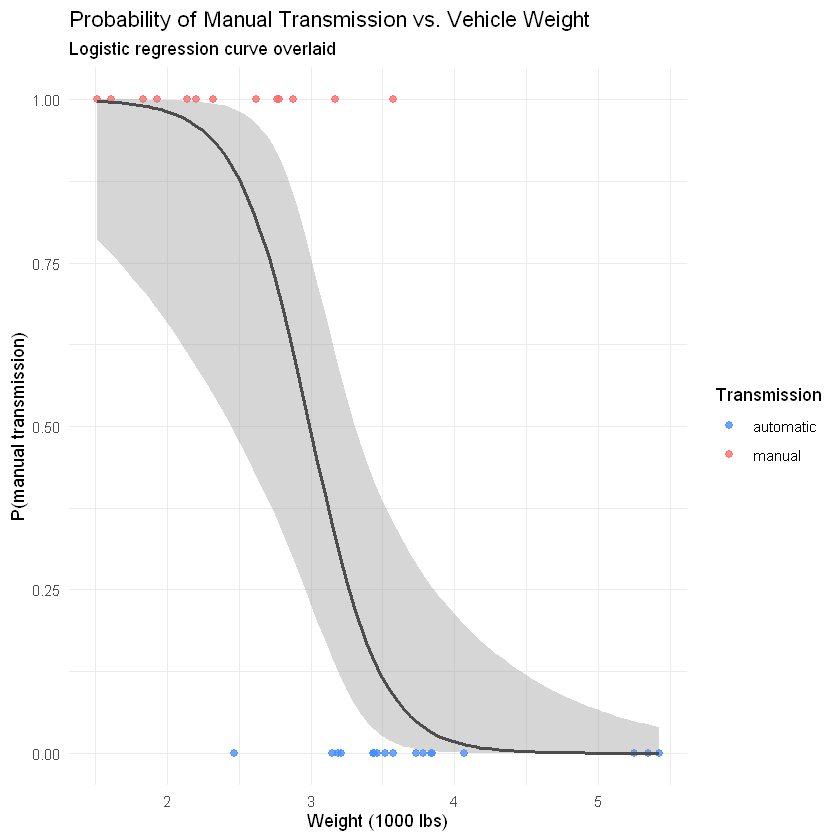

In [2]:
# ── Prepare data ──────────────────────────────────────────────────────────────
cars_logit <- mtcars %>%
  select(am, wt, hp, mpg) %>%
  mutate(am = factor(am, levels = c(0,1), labels = c("automatic", "manual")))

# ── Outcome balance ───────────────────────────────────────────────────────────
table(cars_logit$am)
prop.table(table(cars_logit$am))
# Note: with small n, severe imbalance (< 10% minority class) is problematic

# ── Exploratory plots ─────────────────────────────────────────────────────────
ggplot(cars_logit, aes(x = wt, y = as.numeric(am) - 1, color = am)) +
  geom_point(size = 2, alpha = 0.8) +
  geom_smooth(method = "glm",
              method.args = list(family = binomial),
              se = TRUE, color = "gray30") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b")) +
  labs(title = "Probability of Manual Transmission vs. Vehicle Weight",
       subtitle = "Logistic regression curve overlaid",
       x = "Weight (1000 lbs)", y = "P(manual transmission)",
       color = "Transmission") +
  theme_minimal()

---

## Assumptions Testing

   MLE of lambda Score Statistic (t) Pr(>|t|)  
wt     -0.088743              2.2318  0.03412 *
hp      3.205811              0.8980  0.37711  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

iterations =  13 

Score test for null hypothesis that all lambdas = 1:
F = 3.6654, df = 2 and 27, Pr(>F) = 0.03905


wt       hp 
2.444297 2.444297

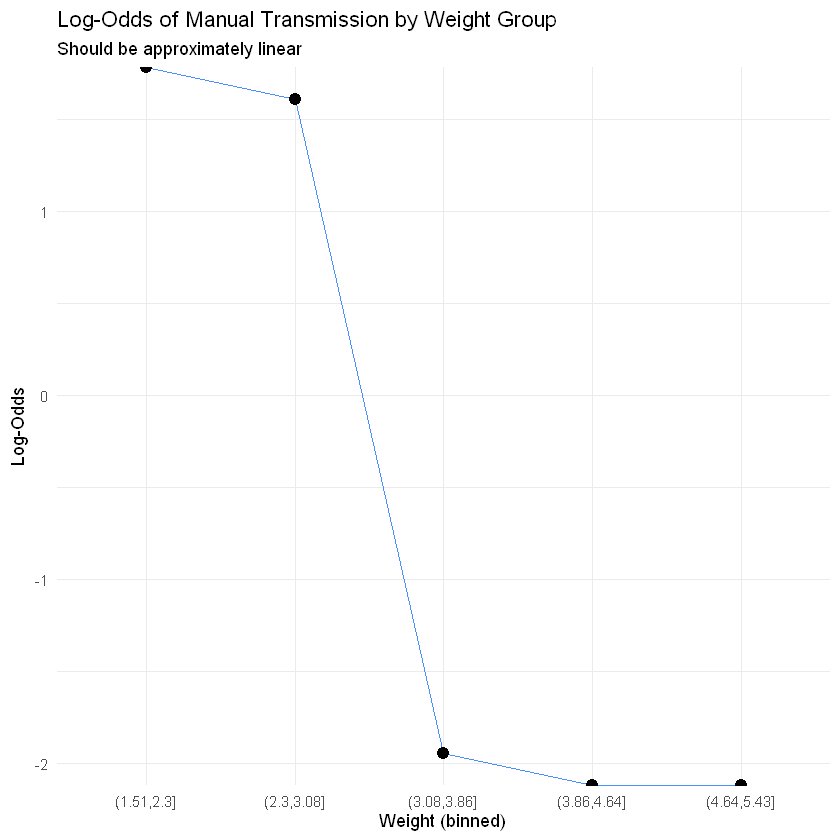

In [3]:
# ── Fit initial model for assumption checks ───────────────────────────────────
model_logit <- glm(am ~ wt + hp, data = cars_logit, family = binomial)

# ── Linearity of log-odds: Box-Tidwell test ───────────────────────────────────
# Tests whether log(predictor) interaction is significant
# Non-significant → linearity of log-odds assumption met
car::boxTidwell(am ~ wt + hp,
                data = cars_logit %>% mutate(am = as.numeric(am) - 1))

# ── Alternative: plot log-odds vs. predictor ──────────────────────────────────
# Bin continuous predictor and compute observed log-odds per bin
cars_logit %>%
  mutate(am_num = as.numeric(am) - 1,
         wt_bin = cut(wt, breaks = 5)) %>%
  group_by(wt_bin) %>%
  summarise(p = mean(am_num), .groups = "drop") %>%
  mutate(logodds = log(p / (1 - p))) %>%
  ggplot(aes(x = wt_bin, y = logodds, group = 1)) +
  geom_line(color = "#4a8fff") +
  geom_point(size = 3) +
  labs(title = "Log-Odds of Manual Transmission by Weight Group",
       subtitle = "Should be approximately linear",
       x = "Weight (binned)", y = "Log-Odds") +
  theme_minimal()

# ── Multicollinearity ─────────────────────────────────────────────────────────
car::vif(model_logit)
# VIF < 5: acceptable

---

## Model Fitting & Output

In [4]:
# ── Fit model ────────────────────────────────────────────────────────────────
model_logit <- glm(am ~ wt + hp,
                   data   = cars_logit,
                   family = binomial(link = "logit"))
summary(model_logit)
# Output: log-odds coefficients, not probabilities or odds ratios directly

# ── Odds ratios: exponentiate coefficients ────────────────────────────────────
exp(coef(model_logit))          # point estimates
exp(confint(model_logit))       # 95% CIs (profile likelihood — preferred)

# Tidy version with ORs and CIs in one table
broom::tidy(model_logit, exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── Predicted probabilities ───────────────────────────────────────────────────
# type = "response" converts log-odds to probability scale
cars_logit$pred_prob <- predict(model_logit, type = "response")

# Predicted class using 0.5 threshold (adjust based on context)
cars_logit$pred_class <- ifelse(cars_logit$pred_prob >= 0.5, "manual", "automatic")


Call:
glm(formula = am ~ wt + hp, family = binomial(link = "logit"), 
    data = cars_logit)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept) 18.86630    7.44356   2.535  0.01126 * 
wt          -8.08348    3.06868  -2.634  0.00843 **
hp           0.03626    0.01773   2.044  0.04091 * 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 43.230  on 31  degrees of freedom
Residual deviance: 10.059  on 29  degrees of freedom
AIC: 16.059

Number of Fisher Scoring iterations: 8


(Intercept)           wt           hp 
1.561455e+08 3.085967e-04 1.036921e+00

Waiting for profiling to be done...

Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted proba

,2.5 %,97.5 %
(Intercept),4.342767e+03,4.083258e+17
wt,3.360155e-08,2.298141e-02
hp,1.010665e+00,1.094781e+00


Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.561455e+08,7.444,2.535,0.011,4342.767,4.083258e+17
wt,0.000000e+00,3.069,-2.634,0.008,0.000,2.300000e-02
hp,1.037000e+00,0.018,2.044,0.041,1.011,1.095000e+00


---

## Model Evaluation

           Actual
Predicted   automatic manual
  automatic        18      1
  manual            1     12
Accuracy: 93.8%


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.9838


	Hosmer and Lemeshow goodness of fit (GOF) test

data:  as.numeric(cars_logit$am) - 1, cars_logit$pred_prob
X-squared = 4.9517, df = 8, p-value = 0.7627


# R2 for Logistic Regression
  Tjur's R2: 0.811

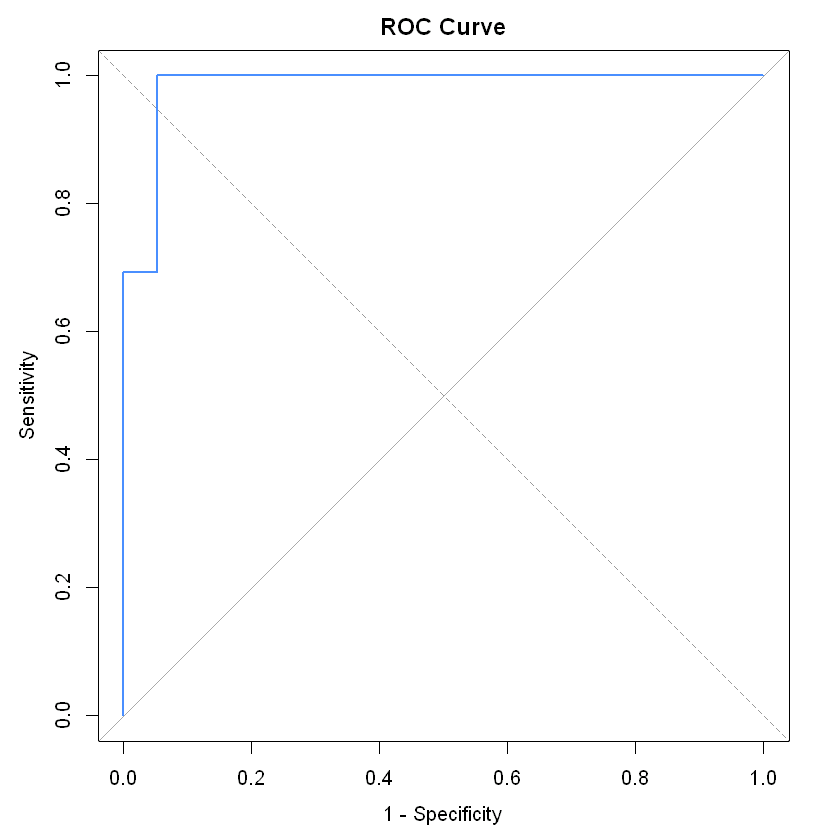

In [5]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
conf_mat <- table(
  Predicted = cars_logit$pred_class,
  Actual    = cars_logit$am
)
print(conf_mat)

# Accuracy
accuracy <- sum(diag(conf_mat)) / sum(conf_mat)
cat(sprintf("Accuracy: %.1f%%\n", accuracy * 100))

# ── ROC curve and AUC ─────────────────────────────────────────────────────────
roc_obj <- pROC::roc(
  response  = as.numeric(cars_logit$am) - 1,
  predictor = cars_logit$pred_prob
)
pROC::auc(roc_obj)
# AUC interpretation:
# 0.5: no discrimination (random)
# 0.7-0.8: acceptable
# 0.8-0.9: excellent
# > 0.9: outstanding

plot(roc_obj,
     main   = "ROC Curve",
     col    = "#4a8fff",
     legacy.axes = TRUE)
abline(a = 0, b = 1, lty = 2, col = "gray60")  # random classifier baseline

# ── Hosmer-Lemeshow goodness-of-fit ──────────────────────────────────────────
# Tests whether predicted probabilities match observed outcomes across deciles
# H0: model fits well
# p > 0.05: no evidence of poor fit
ResourceSelection::hoslem.test(
  x = as.numeric(cars_logit$am) - 1,
  y = cars_logit$pred_prob,
  g = 10
)

# ── Pseudo R² (model fit, not variance explained) ────────────────────────────
performance::r2(model_logit)
# McFadden's R²: 0.2-0.4 indicates excellent fit
# Compare to null model — not directly interpretable as variance explained

---

## Visualizing Predictions

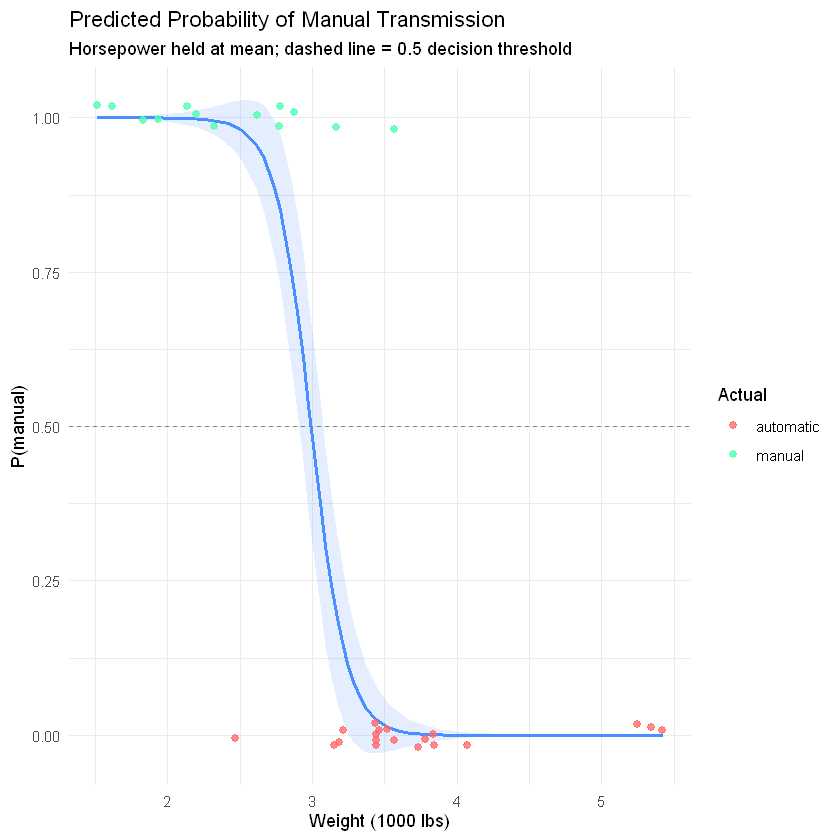

In [6]:
# ── Predicted probability curve over range of weight ─────────────────────────
pred_df <- expand.grid(
  wt = seq(min(mtcars$wt), max(mtcars$wt), length.out = 100),
  hp = mean(mtcars$hp)  # hold hp at its mean
) %>%
  mutate(pred_prob = predict(model_logit, newdata = ., type = "response"))

ggplot() +
  geom_ribbon(data = pred_df,
              aes(x = wt,
                  ymin = pred_prob - 1.96 * sqrt(pred_prob*(1-pred_prob)/nrow(mtcars)),
                  ymax = pred_prob + 1.96 * sqrt(pred_prob*(1-pred_prob)/nrow(mtcars))),
              alpha = 0.15, fill = "#4a8fff") +
  geom_line(data = pred_df, aes(x = wt, y = pred_prob),
            color = "#4a8fff", linewidth = 1) +
  geom_jitter(data = cars_logit,
              aes(x = wt, y = as.numeric(am) - 1, color = am),
              height = 0.02, size = 2, alpha = 0.8) +
  scale_color_manual(values = c("#ff6b6b", "#4fffb0")) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray50") +
  labs(title = "Predicted Probability of Manual Transmission",
       subtitle = "Horsepower held at mean; dashed line = 0.5 decision threshold",
       x = "Weight (1000 lbs)",
       y = "P(manual)",
       color = "Actual") +
  theme_minimal()

---

## Reporting Results

In [7]:
# ── Full results table ────────────────────────────────────────────────────────
broom::tidy(model_logit, exponentiate = TRUE, conf.int = TRUE) %>%
  rename(OR = estimate, lower_95 = conf.low, upper_95 = conf.high) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── Model fit ─────────────────────────────────────────────────────────────────
cat(sprintf("AUC = %.3f\n", as.numeric(pROC::auc(roc_obj))))
cat(sprintf("McFadden R² = %.3f\n",
            as.numeric(performance::r2(model_logit)$R2_McFadden)))

# Standard reporting format:
# "Vehicle weight was a significant negative predictor of manual transmission
#  (OR = 0.03, 95% CI [0.001, 0.28], p = .006): heavier vehicles had lower
#  odds of manual transmission. The model showed good discrimination
#  (AUC = 0.93, McFadden R² = 0.59)."

Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"

term,OR,std.error,statistic,p.value,lower_95,upper_95
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.561455e+08,7.444,2.535,0.011,4342.767,4.083258e+17
wt,0.000000e+00,3.069,-2.634,0.008,0.000,2.300000e-02
hp,1.037000e+00,0.018,2.044,0.041,1.011,1.095000e+00


AUC = 0.984


---

## Common Pitfalls

**1. Interpreting coefficients as probabilities**  
Raw `glm` coefficients are log-odds, not probabilities. Exponentiate to get odds ratios; use `predict(type = "response")` to get predicted probabilities.

**2. Using the wrong threshold for classification**  
The default 0.5 threshold is rarely optimal. In imbalanced datasets (e.g., rare fraud, rare disease), a lower threshold reduces false negatives at the cost of more false positives. Choose the threshold based on the relative costs of each error type in context.

**3. Reporting accuracy alone for imbalanced outcomes**  
A model that always predicts the majority class has high accuracy but no predictive value. Use AUC, precision-recall, F1, or sensitivity/specificity for imbalanced outcomes.

**4. Not checking for complete separation**  
If a predictor perfectly separates the two groups, the algorithm converges on infinite coefficients. Warning signs: very large coefficients, inflated standard errors. Solution: penalized regression (Firth's method via `logistf` package).

**5. Ignoring the EPV rule**  
With too few events relative to predictors, coefficients are unreliable. Aim for at least 10-20 events (occurrences of the rarer outcome) per predictor in the model.

**6. Using pseudo R² as variance explained**  
McFadden's R² and similar measures are not directly analogous to R² in linear regression. Use AUC and calibration metrics as primary evaluation tools.

---

## Extensions

| Situation | Solution |
|---|---|
| Outcome has 3+ unordered categories | Multinomial regression (`multinomial_regression.ipynb`) |
| Outcome has 3+ ordered categories | Ordinal regression (`ordinal_regression.ipynb`) |
| Severe class imbalance | SMOTE or cost-sensitive learning (`10_classification/imbalanced_data.ipynb`) |
| Non-independent observations | Mixed effects logistic regression (`03_mixed_effects_models/glmm_basics.ipynb`) |
| Many predictors | Regularized logistic regression (`regularized_regression.ipynb`) |

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*